# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Tesher Baer

**Date:** 9/11/2026

(28221, 10)
['ID', 'OPEID', 'Institution Name', 'City', 'State', 'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type', 'Country of Giftor', 'Giftor Name']
   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476       Contract   

  Country

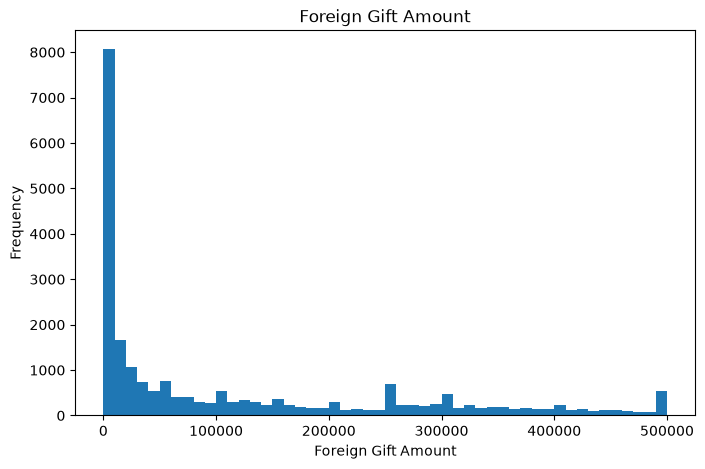

The findings show an extreme right skew in the distribution of foreign gift amounts, with most gifts being relatively small and a few very large gifts. This suggests that while many foreign gifts are modest, there are some outliers that significantly increase the average gift amount.


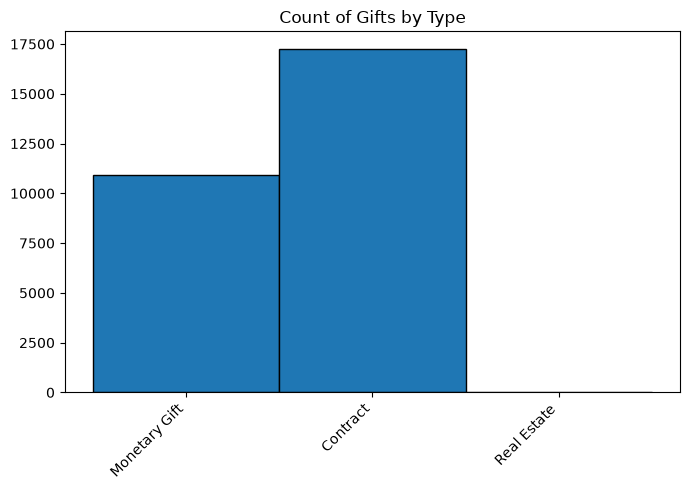

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


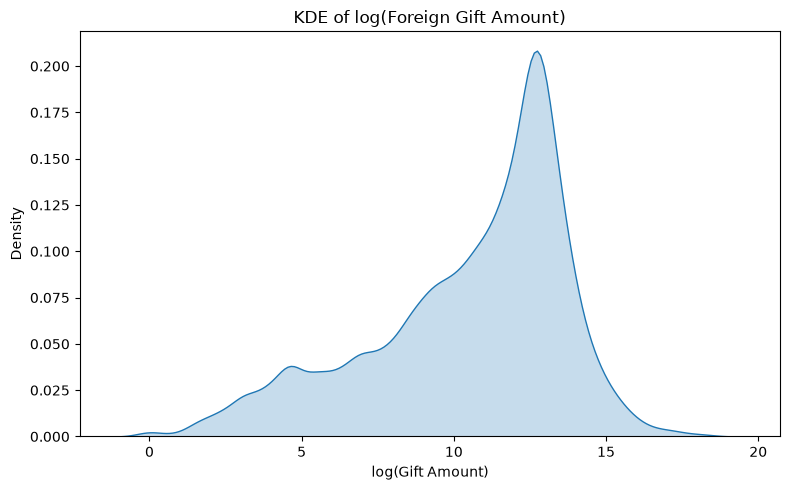

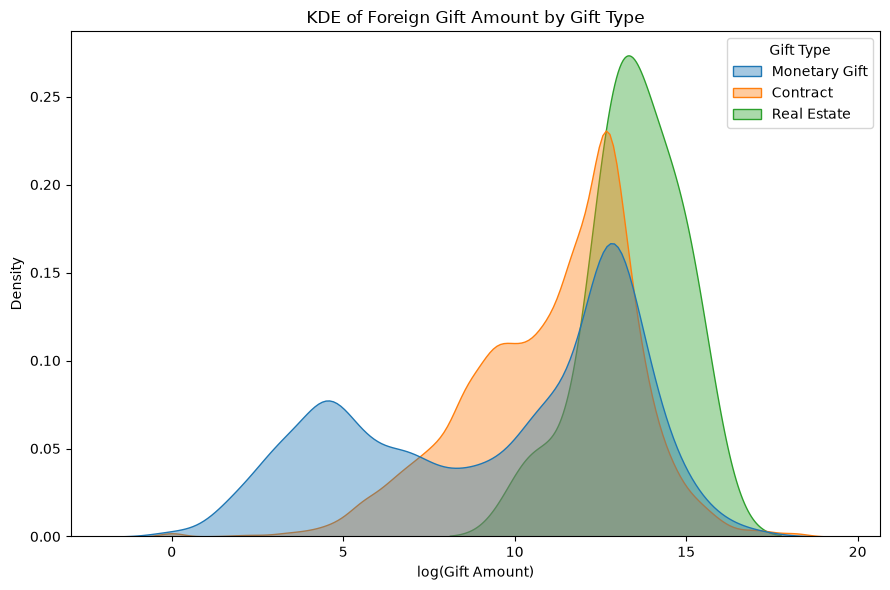

Top 15 countries by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Top 15 countries by total amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                4011576

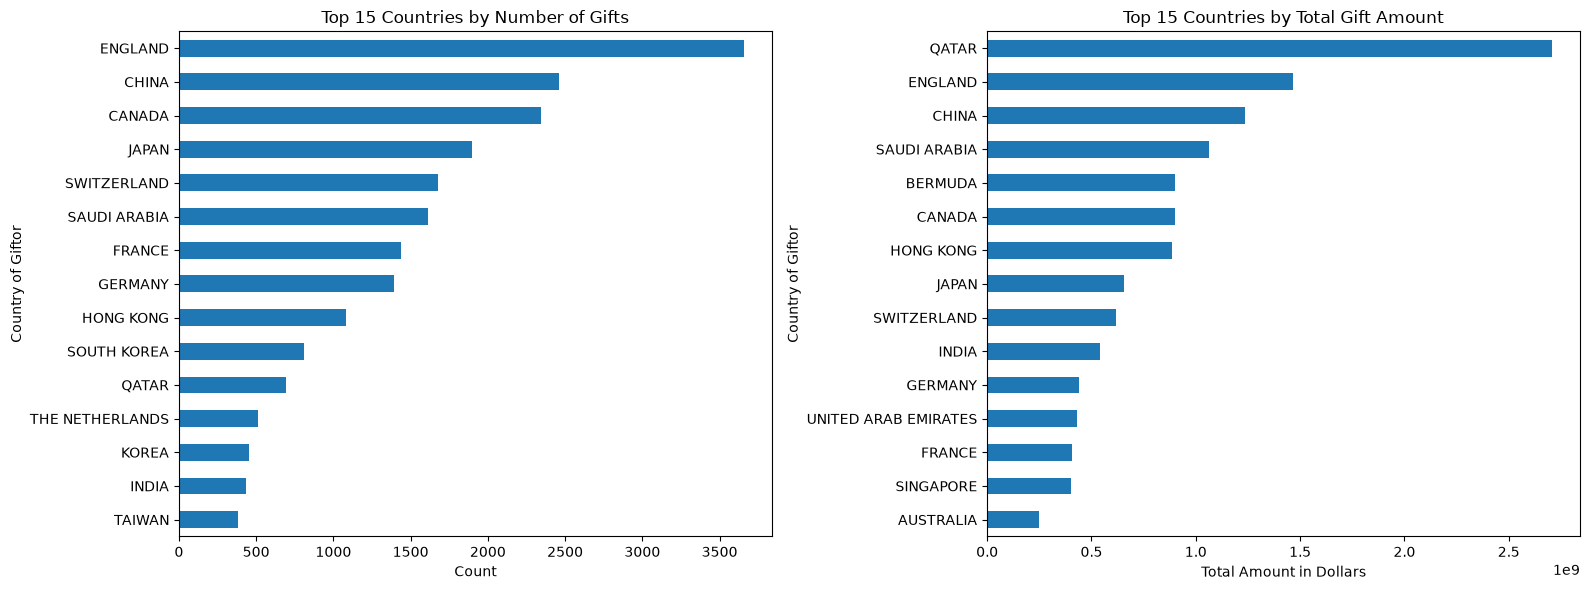

Top giftors by total amount given:
Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


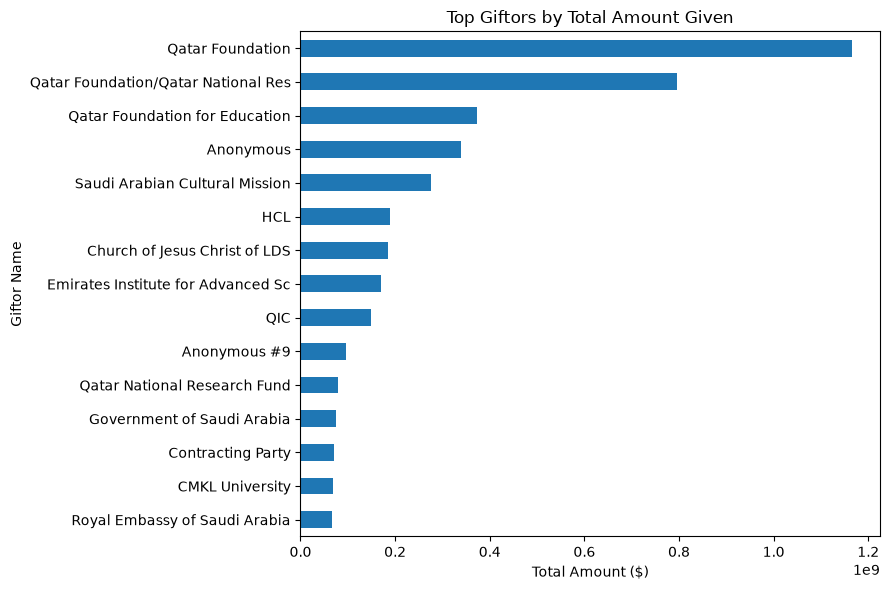

In [ ]:
# Your Phase 1 solution to the problem goes here.

#import packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install seaborn

import seaborn as sns 

#part 1: import data 
df = pd.read_csv('data/ForeignGifts_edu.csv') 
df.head()

print(df.shape)
print(df.columns.tolist())
print(df.head())

#part 2: create histogram for Foreign Gift Amount 
plt.figure(figsize=(8,5))
plt.hist(df['Foreign Gift Amount'], bins=50, range=(0, 500000))
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title('Foreign Gift Amount')
plt.show() 
print("The findings show an extreme right skew in the distribution of foreign gift amounts, " \
"with most gifts being relatively small and a few very large gifts. " \
"This suggests that while many foreign gifts are modest, there are some outliers that " \
"significantly increase the average gift amount.")

#part 3 create histogram for Gift Type
plt.figure(figsize=(7, 5))
plt.hist(df['Gift Type'], bins=np.arange(len(df['Gift Type'].unique()) + 1) - 0.5, edgecolor='black')
plt.title("Count of Gifts by Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#what proportion are real estate, contracts, and monetary 
counts = df['Gift Type'].value_counts()
props = df['Gift Type'].value_counts(normalize=True)

print(counts)
print(props)

#kernel density plot
#note that these are done in log scale for better viz, as a linear representation is very hard to read
AMOUNT_COL = "Foreign Gift Amount"
TYPE_COL = "Gift Type"

df["log_amount"] = np.log(df[AMOUNT_COL].clip(lower=1))  
 
plt.figure(figsize=(8, 5))
sns.kdeplot(df["log_amount"], fill=True)
plt.title("KDE of log(Foreign Gift Amount)")
plt.xlabel("log(Gift Amount)")
plt.tight_layout()
plt.show()
 
plt.figure(figsize=(9, 6))
sns.kdeplot(data=df, x="log_amount", hue=TYPE_COL, fill=True, common_norm=False, alpha=0.4)
plt.title("KDE of Foreign Gift Amount by Gift Type")
plt.xlabel("log(Gift Amount)")
plt.tight_layout()
plt.show()

#part 5
COUNTRY_COL = "Country of Giftor"

top15_by_count = (
    df.groupby([COUNTRY_COL]).count()[AMOUNT_COL]
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 countries by number of gifts:")
print(top15_by_count)
 
top15_by_amount = (
    df.groupby([COUNTRY_COL]).sum(numeric_only=True)[AMOUNT_COL]
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 countries by total amount given:")
print(top15_by_amount)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top15_by_count.plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Countries by Number of Gifts")
axes[0].set_xlabel("Count")
 
top15_by_amount.plot(kind="barh", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Countries by Total Gift Amount")
axes[1].set_xlabel("Total Amount in Dollars")
 
plt.tight_layout()
plt.show()

#part 6
GIFTOR_COL = "Giftor Name"

top_giftors = (
    df.groupby([GIFTOR_COL]).sum(numeric_only=True)[AMOUNT_COL]
    .sort_values(ascending=False)
    .head(15)
)
print("Top giftors by total amount given:")
print(top_giftors)
 
plt.figure(figsize=(9, 6))
top_giftors.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top Giftors by Total Amount Given")
plt.xlabel("Total Amount ($)")
plt.tight_layout()
plt.show()



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** Claude 

### *Prompts used

1. Given the attached prompts, what changes would you make to the following responses, if any are necessary?
2. (For question 2) Given the following prompts, are there any changes you would make to the attached code to better respond to the prompts?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. For question 1: No changes would affect the final result of the answer, but there are a few spots where the reasoning has gaps or notation issues worth tightening up. 
2. For question 2: Add a descriptor to number 2, (print(df['Foreign Gift Amount'].describe())) 
3. Neglected to isolate Contracts, Monetary Gifts, and Real Estate in print, so add the following (target_types = ['Contract', 'Real Estate Gift', 'Monetary Gift']  # match exact strings in your data
print(props.loc[props.index.intersection(target_types)]))
4. Also in question 2, only counted non null values, so change to df.groupby([COUNTRY_COL]).count()[AMOUNT_COL]
5. 

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject. : I decided to accept all suggestions to question 2, as it did genuinely catch mistakes that I had made in leaving out key details. For question 1, I opted to keep my original work, as the actual answers (and logic) themselves remained unchanged by AI's additions. 

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

(28221, 10)
['ID', 'OPEID', 'Institution Name', 'City', 'State', 'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type', 'Country of Giftor', 'Giftor Name']
   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476       Contract   

  Country

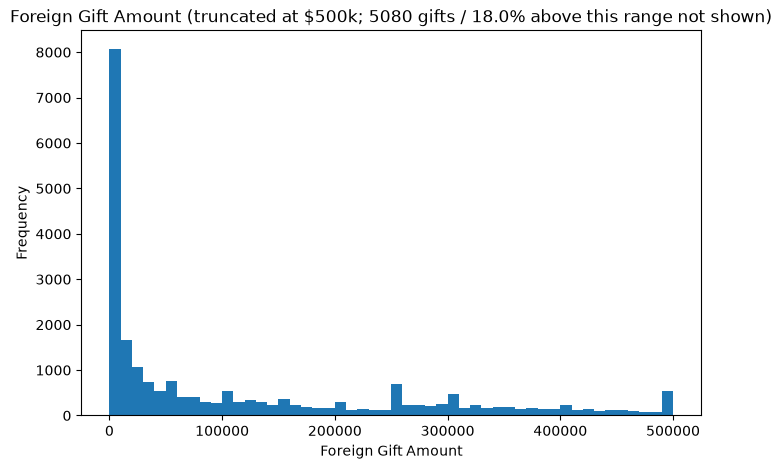

The findings show an extreme right skew in the distribution of foreign gift amounts, with most gifts being relatively small and a few very large gifts. 5080 gifts (18.0% of the data) exceed $500,000 and fall outside the truncated range shown above, which is why the log-scale KDE plots later are more informative for this variable. This suggests that while many foreign gifts are modest, there are some outliers that significantly increase the average gift amount.


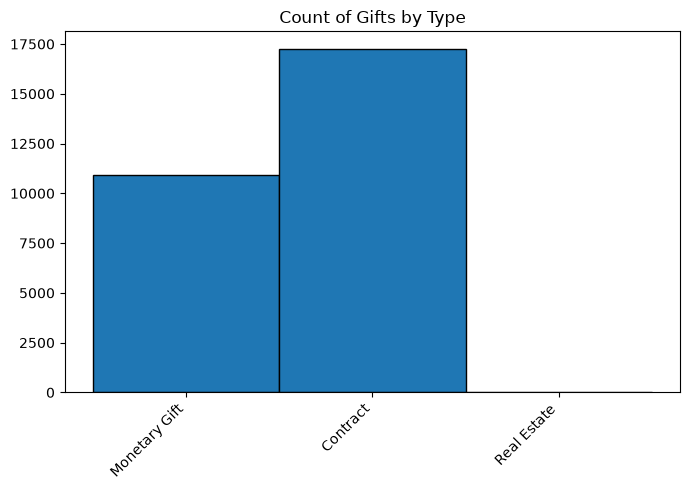

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
Unique Gift Type values: <StringArray>
['Monetary Gift', 'Contract', 'Real Estate']
Length: 3, dtype: str
Proportion for contracts, real estate, and monetary gifts:
Gift Type
Monetary Gift    0.387513
Contract         0.612097
Real Estate      0.000390
Name: proportion, dtype: float64


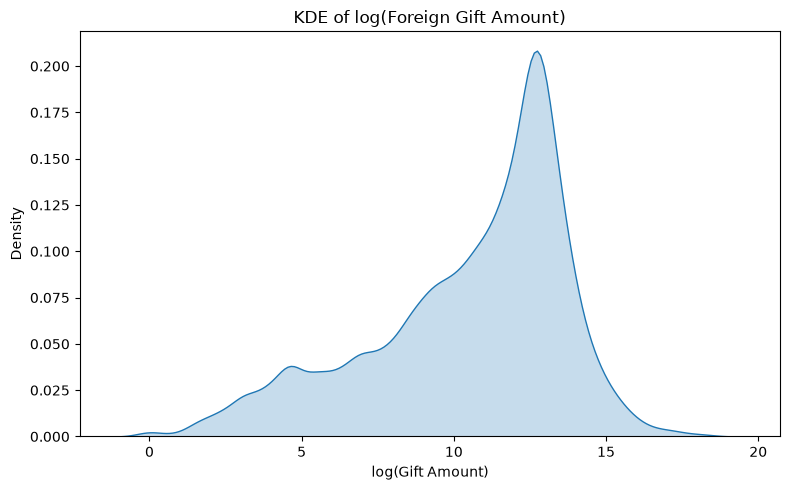

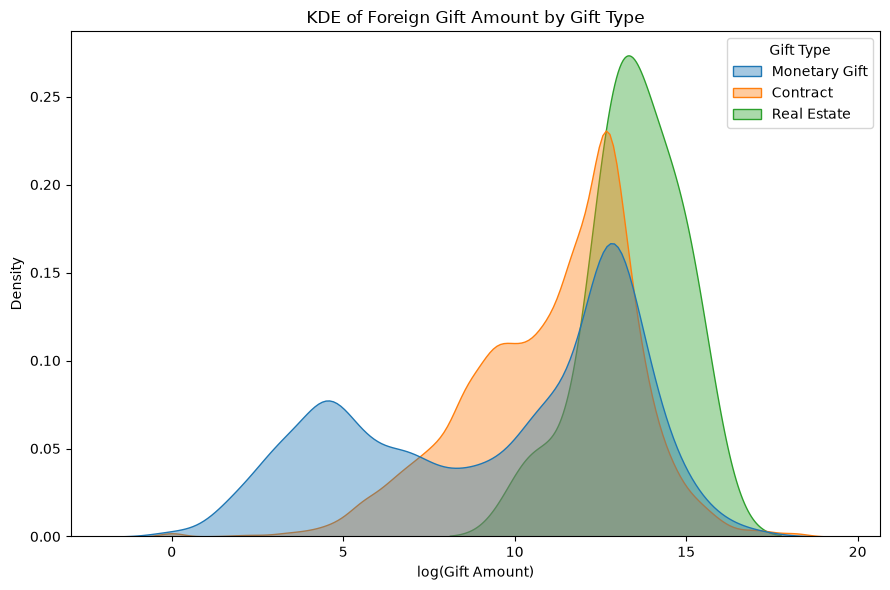

Pattern check: compare where each gift type's density peaks and how wide each distribution is on the log scale. Gift types whose curves are shifted right have higher typical dollar amounts; types with narrower curves are more consistent in size, while wider/flatter curves indicate more variability within that gift type. [Replace this line with the specific pattern you actually observe in your output.]
Missing values in Foreign Gift Amount: 0
Top 15 countries by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Top 15 countries by total amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 146490677

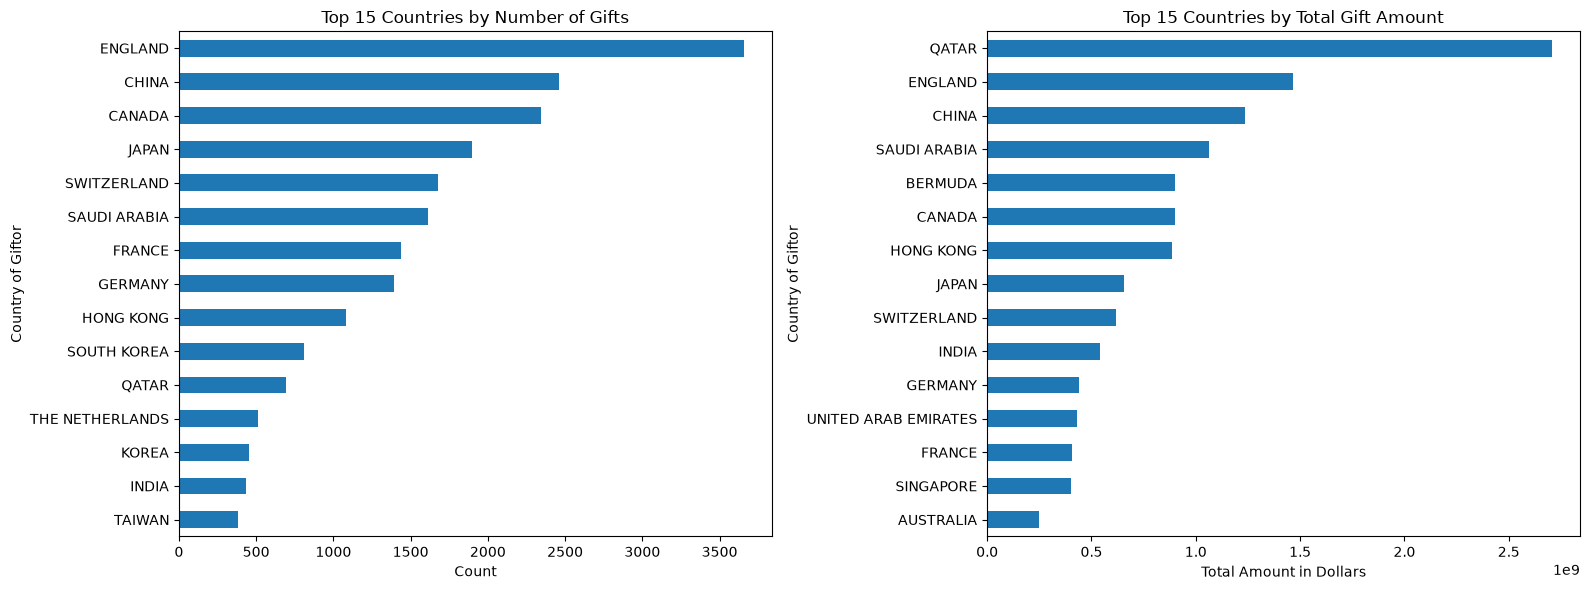

Top giftors by total amount given:
Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


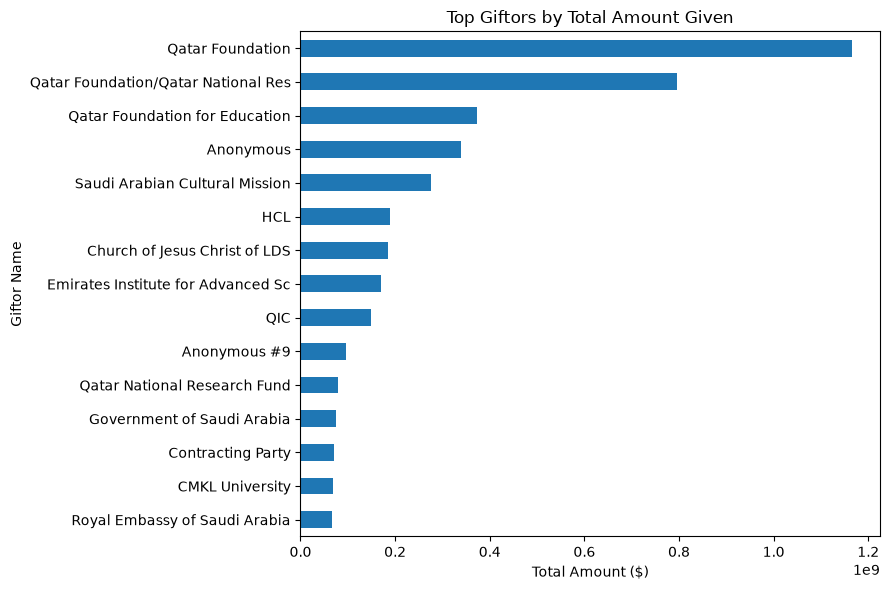

In [2]:
# Your Phase 2 solution to the problem goes here.

#import packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
# Note: seaborn install moved out of the notebook. Run `pip install seaborn`
# once in your environment/terminal rather than shelling out on every run.

#part 1: import data 
df = pd.read_csv('data/ForeignGifts_edu.csv') 
df.head()

print(df.shape)
print(df.columns.tolist())
print(df.head())

#part 2: create histogram for Foreign Gift Amount 
AMOUNT_COL = "Foreign Gift Amount"

# Descriptive stats for the variable (mean, std, quartiles, min/max)
print(df[AMOUNT_COL].describe())

n_over_500k = (df[AMOUNT_COL] > 500000).sum()
pct_over_500k = n_over_500k / len(df) * 100

plt.figure(figsize=(8,5))
plt.hist(df[AMOUNT_COL], bins=50, range=(0, 500000))
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title(f'Foreign Gift Amount (truncated at $500k; '
          f'{n_over_500k} gifts / {pct_over_500k:.1f}% above this range not shown)')
plt.show() 
print(f"The findings show an extreme right skew in the distribution of foreign gift amounts, "
      f"with most gifts being relatively small and a few very large gifts. "
      f"{n_over_500k} gifts ({pct_over_500k:.1f}% of the data) exceed $500,000 and fall outside "
      f"the truncated range shown above, which is why the log-scale KDE plots later are more "
      f"informative for this variable. This suggests that while many foreign gifts are modest, "
      f"there are some outliers that significantly increase the average gift amount.")

#part 3 create histogram for Gift Type
TYPE_COL = "Gift Type"

plt.figure(figsize=(7, 5))
plt.hist(df[TYPE_COL], bins=np.arange(len(df[TYPE_COL].unique()) + 1) - 0.5, edgecolor='black')
plt.title("Count of Gifts by Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#what proportion are real estate, contracts, and monetary 
counts = df[TYPE_COL].value_counts()
props = df[TYPE_COL].value_counts(normalize=True)

print(counts)
print(props)

# Check exact category labels before filtering, since CSV wording may not
# exactly match "contracts / real estate / monetary"
print("Unique Gift Type values:", df[TYPE_COL].unique())

target_types = [t for t in df[TYPE_COL].unique()
                 if any(key in t.lower() for key in ["contract", "real estate", "monetary"])]
print("Proportion for contracts, real estate, and monetary gifts:")
print(props.loc[target_types])

#kernel density plot
#note that these are done in log scale for better viz, as a linear representation is very hard to read
df["log_amount"] = np.log(df[AMOUNT_COL].clip(lower=1))  
 
plt.figure(figsize=(8, 5))
sns.kdeplot(df["log_amount"], fill=True)
plt.title("KDE of log(Foreign Gift Amount)")
plt.xlabel("log(Gift Amount)")
plt.tight_layout()
plt.show()
 
plt.figure(figsize=(9, 6))
sns.kdeplot(data=df, x="log_amount", hue=TYPE_COL, fill=True, common_norm=False, alpha=0.4)
plt.title("KDE of Foreign Gift Amount by Gift Type")
plt.xlabel("log(Gift Amount)")
plt.tight_layout()
plt.show()

print("Pattern check: compare where each gift type's density peaks and how wide each "
      "distribution is on the log scale. Gift types whose curves are shifted right have "
      "higher typical dollar amounts; types with narrower curves are more consistent in size, "
      "while wider/flatter curves indicate more variability within that gift type. "
      "[Replace this line with the specific pattern you actually observe in your output.]")

#part 5
COUNTRY_COL = "Country of Giftor"

# .size() counts rows per group regardless of missing values in AMOUNT_COL;
# .count() would undercount if Foreign Gift Amount has any NaNs.
n_missing_amount = df[AMOUNT_COL].isna().sum()
print(f"Missing values in {AMOUNT_COL}: {n_missing_amount}")

top15_by_count = (
    df.groupby(COUNTRY_COL).size()
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 countries by number of gifts:")
print(top15_by_count)
 
top15_by_amount = (
    df.groupby([COUNTRY_COL]).sum(numeric_only=True)[AMOUNT_COL]
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 countries by total amount given:")
print(top15_by_amount)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top15_by_count.plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Countries by Number of Gifts")
axes[0].set_xlabel("Count")
 
top15_by_amount.plot(kind="barh", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Countries by Total Gift Amount")
axes[1].set_xlabel("Total Amount in Dollars")
 
plt.tight_layout()
plt.show()

#part 6
GIFTOR_COL = "Giftor Name"

top_giftors = (
    df.groupby([GIFTOR_COL]).sum(numeric_only=True)[AMOUNT_COL]
    .sort_values(ascending=False)
    .head(15)
)
print("Top giftors by total amount given:")
print(top_giftors)
 
plt.figure(figsize=(9, 6))
top_giftors.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top Giftors by Total Amount Given")
plt.xlabel("Total Amount ($)")
plt.tight_layout()
plt.show()

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I found AI to be far more helpful in this go around than in Lab 1, as I am kind of reaching the limit of my current coding skillset, so having an LLM look over my shoulder to verify that I had not left anything out or made a simple mistake was extremely useful. The main improvements were to add more descriptors, which is something I have always struggled with in my coding. It is able to interpret code much more quickly than I can, and it of courses has a far larger grasp on other functions that can produce the same or better looking results. For instance, AI can make a much nicer looking graph than I can, so I have had to rely on code I used for graphs and figures in another data visualization class so that my figures are clear. I verified the final solution by running the code again and cross referencing it against the original, phase 1 code. I do not have any concerns at this point about the utility of AI in this context. 